In [43]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from sunpy.coordinates import HeliographicStonyhurst, HeliographicCarrington
from sunpy.coordinates import RotatedSunFrame
import sunpy.coordinates.frames as frames
import matplotlib.pyplot as plt

In [64]:
rs_hgc = RotatedSunFrame(base=frames.HeliographicCarrington(10*u.deg, 0*u.deg, observer="earth",
                                                       obstime="2020-03-04 00:00"),
                         rotated_time="2020-03-06 12:00")
rs_hgc

<RotatedSunHeliographicCarrington Coordinate (base=<HeliographicCarrington Frame (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=2.5 d, rotation_model=howard): (lon, lat) in deg
    (10., 0.)>

In [66]:
rs_hgc_2 = SkyCoord(RotatedSunFrame(base=frames.HeliographicCarrington(10*u.deg, 0*u.deg, observer="earth",
                                                       obstime="2020-03-04 00:00"),
                         rotated_time="2020-03-06 12:00"))

In [72]:
test = SkyCoord(20*u.deg, 0*u.deg, frame=rs_hgc)
test

aa=RotatedSunFrame(base=frames.HeliographicCarrington(20*u.deg, 0*u.deg, observer="earth",
                                                       obstime="2020-03-04 00:00"),
                         rotated_time="2020-03-06 12:00")
aa.transform_to(aa.base)

<HeliographicCarrington Coordinate (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (55.81582096, 0., 695700.)>

In [65]:
(rs_hgc.transform_to(rs_hgc.base).lon.deg-10)/14.33

np.float64(2.4993594526689336)

In [71]:
rs_hgc.transform_to(rs_hgc.base), rs_hgc_2.transform_to(rs_hgc_2.base), test.transform_to(test.base)


(<HeliographicCarrington Coordinate (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
     (45.81582096, 0., 695700.)>,
 <SkyCoord (HeliographicCarrington: obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
     (45.81582096, 0., 695700.)>,
 <SkyCoord (HeliographicCarrington: obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
     (55.81582096, 0., 695700.)>)

In [84]:
durations = range(-5, 6, 1)*u.day
ar_start = frames.HeliographicCarrington(20*u.deg, 5*u.deg,
                             obstime="2001-01-01", observer="earth")
ar = SkyCoord(RotatedSunFrame(base=ar_start, duration=durations))
ar.transform_to(ar.base)

<SkyCoord (HeliographicCarrington: obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    [(308.44935803, 5., 695700.), (322.75948643, 5., 695700.),
     (337.06961482, 5., 695700.), (351.37974321, 5., 695700.),
     (  5.68987161, 5., 695700.), ( 20.        , 5., 695700.),
     ( 34.31012839, 5., 695700.), ( 48.62025679, 5., 695700.),
     ( 62.93038518, 5., 695700.), ( 77.24051357, 5., 695700.),
     ( 91.55064197, 5., 695700.)]>

In [85]:
import numpy as np
point = SkyCoord(20*u.deg, 5*u.deg, frame=frames.HeliographicCarrington(obstime="2001-01-01", observer="earth"))
durations = np.array([-5,-4,-3,-2,-1,0,1,2,3,4,5]) * u.day
diffrot_point = RotatedSunFrame(base=point, duration=durations)
# 看真实位置：转回普通 frame
diffrot_point.transform_to(point.frame)

<HeliographicCarrington Coordinate (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    [(308.44935803, 5., 695700.), (322.75948643, 5., 695700.),
     (337.06961482, 5., 695700.), (351.37974321, 5., 695700.),
     (  5.68987161, 5., 695700.), ( 20.        , 5., 695700.),
     ( 34.31012839, 5., 695700.), ( 48.62025679, 5., 695700.),
     ( 62.93038518, 5., 695700.), ( 77.24051357, 5., 695700.),
     ( 91.55064197, 5., 695700.)]>

In [89]:
t0 = "2001-01-01"; Δt = 5*u.day

# 在 t0 的位置
A = SkyCoord(20*u.deg, 5*u.deg,
             frame=frames.HeliographicCarrington(obstime=t0, observer="earth"))

# 模式 2（正向）：A 自转 +5 天后到哪里
forward = SkyCoord(RotatedSunFrame(base=A, duration=Δt)).transform_to(A.frame)
print("forward lon:", forward)   # ≈ 20° + 5×ω(lat=5°)

# 模式 3（反向）：把 A 当作 t1 观测到的点，问它 5 天前来自哪里
target = RotatedSunFrame(base=A.frame, duration=Δt)   # base frame 仍在 t0
backward = A.transform_to(target)
print("backward stored:", backward)
print("backward as_base:", backward.as_base())    # ≈ 20° - 5×ω(lat=5°)

forward lon: <SkyCoord (HeliographicCarrington: obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (91.55064197, 5., 695700.)>
backward stored: <SkyCoord (RotatedSunHeliographicCarrington: base=<HeliographicCarrington Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=5.0 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, km)
    (-51.55064197, 5., 695700.)>
backward as_base: <HeliographicCarrington Coordinate (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (308.44935803, 5., 695700.)>


In [44]:
from sunpy.map import Map
from pathlib import Path
# DATA_DIR = (Path.cwd().parent / 'data').resolve()
# DATA_DIR
hmi_synop = Map('../data/hmi.synoptic_mr_polfil_720s.2254.Mr_polfil.fits')

In [57]:
ft1 = SkyCoord(70*u.deg, 0*u.deg, frame=HeliographicCarrington, obstime=hmi_synop.date, observer='earth')

rs_frame = RotatedSunFrame(base=frames.HeliographicCarrington(observer='earth', obstime='2022-02-22 20:00'), 
                           rotated_time=hmi_synop.date)

print(rs_frame,'\n')
ft2 = ft1.transform_to(rs_frame)
print(ft2,'\n')

ft3 = ft1.transform_to(rs_frame.base)
print(ft3)

<RotatedSunHeliographicCarrington Frame (base=<HeliographicCarrington Frame (obstime=2022-02-22T20:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=-0.9948726851851852 d, rotation_model=howard)> 

<SkyCoord (RotatedSunHeliographicCarrington: base=<HeliographicCarrington Frame (obstime=2022-02-22T20:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=-0.9948726851851852 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, km)
    (70.19446753, -0.00066768, 696878.94442821)> 

<SkyCoord (HeliographicCarrington: obstime=2022-02-22T20:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (55.94159474, -0.00066768, 696878.94442821)>


In [41]:
frame2 = frames.HeliographicCarrington(obstime='2022-02-24 20:00')
frame2_rs = RotatedSunFrame(base=ft1.frame, rotated_time='2022-02-24 20:00')
print(ft1.transform_to(frame2))
print(ft1.transform_to(frame2_rs))

<SkyCoord (HeliographicCarrington: obstime=2022-02-24T20:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (27.67960579, -0.00204237, 699248.8960772)>
<SkyCoord (RotatedSunHeliographicCarrington: base=<HeliographicCarrington Frame (obstime=2022-02-21T20:08:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=2.994872685185185 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, km)
    (27.09447045, 0., 695700.)>


In [26]:
ft1 = SkyCoord(70*u.deg, 0*u.deg, frame=HeliographicCarrington, obstime=hmi_synop.date, observer='earth')

rs_frame = RotatedSunFrame(base=hmi_synop.coordinate_frame, 
                           rotated_time='2022-02-22 20:00')
print(rs_frame)
ft2 = ft1.transform_to(rs_frame)
print(ft2)

ft3 = ft1.transform_to(rs_frame.base)
print(ft3)

<RotatedSunHeliographicCarrington Frame (base=<HeliographicCarrington Frame (obstime=2022-02-21T20:07:23.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-02-21T20:07:23.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0., -7.06885645, 1.4795665e+11)>)>, duration=0.9948726851851852 d, rotation_model=howard)>
<SkyCoord (RotatedSunHeliographicCarrington: base=<HeliographicCarrington Frame (obstime=2022-02-21T20:07:23.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-02-21T20:07:23.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0., -7.06885645, 1.4795665e+11)>)>, duration=0.9948726851851852 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, km)
    (55.74712721, 0., 695700.)>
<SkyCoord (HeliographicCarrington: obstime=2022-02-21T20:07:23.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-02-21T20:07:23.000, rsun=695700.0 km): (lon, lat, radius) in (deg, de

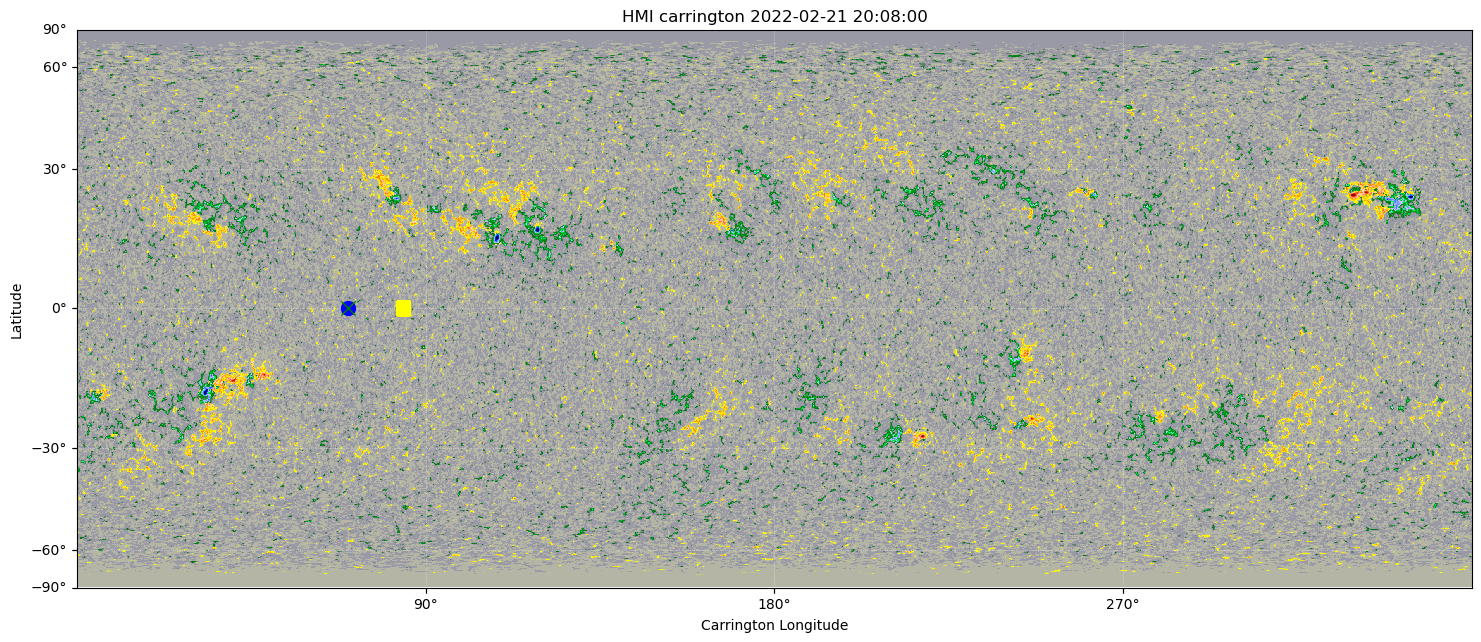

In [54]:

plt.close()
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(111, projection=hmi_synop)
hmi_synop.plot(axes=ax)
ax.plot_coord(ft1, color='red', marker='*', markersize=10)
ax.plot_coord(ft2, color='blue', marker='o', markersize=10)
ax.plot_coord(ft3, color='green', marker='x', markersize=10)
ax.plot_coord(ft0.transform_to(hmi_synop.coordinate_frame), color='yellow', marker='s', markersize=10)

**Coordinates**

In [2]:
from sunpy.coordinates import RotatedSunFrame
import sunpy.coordinates.frames as frames

base_frame = frames.HeliographicStonyhurst(obstime="2001-01-01")
rs_hgs = RotatedSunFrame(base=base_frame, duration=1*u.day)
rs_hgs

<RotatedSunHeliographicStonyhurst Frame (base=<HeliographicStonyhurst Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km)>, duration=1.0 d, rotation_model=howard)>

In [5]:
rotated_coord = SkyCoord(0*u.deg, 0*u.deg, frame=rs_hgs)
print(rotated_coord)
rotated_coord.transform_to(base_frame)


<SkyCoord (RotatedSunHeliographicStonyhurst: base=<HeliographicStonyhurst Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km)>, duration=1.0 d, rotation_model=howard): (lon, lat) in deg
    (0., 0.)>


<SkyCoord (HeliographicStonyhurst: obstime=2001-01-01T00:00:00.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, km)
    (14.32632838, 0., 695700.)>

In [8]:
print(rs_hgs.rotated_time)

2001-01-02T00:00:00.000


In [11]:
rs_hgc = RotatedSunFrame(base=frames.HeliographicCarrington(10*u.deg, 20*u.deg, observer="earth",
                                                       obstime="2020-03-04 00:00"),
                         rotated_time="2020-03-06 12:00")
rs_hgc
SkyCoord(rs_hgc).transform_to(rs_hgc.base)

<SkyCoord (HeliographicCarrington: obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (45.13354448, 20., 695700.)>

In [ ]:
meridian = RotatedSunFrame([100]*11*u.deg, range(-75, 90, 15)*u.deg,
                           base=frames.HeliographicCarrington(observer="earth", obstime="2001-01-01"),
                           duration=1*u.day)
meridian

<RotatedSunHeliographicCarrington Coordinate (base=<HeliographicCarrington Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=1.0 d, rotation_model=howard): (lon, lat) in deg
    [(100., -75.), (100., -60.), (100., -45.), (100., -30.), (100., -15.),
     (100.,   0.), (100.,  15.), (100.,  30.), (100.,  45.), (100.,  60.),
     (100.,  75.)]>

In [13]:
durations = range(-5, 6, 1)*u.day
ar_start = frames.Helioprojective(-123*u.arcsec, 456*u.arcsec,
                             obstime="2001-01-01", observer="earth")
ar = RotatedSunFrame(base=ar_start, duration=durations)
ar

<RotatedSunHelioprojective Coordinate (base=<Helioprojective Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=[-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.] d, rotation_model=howard): (Tx, Ty) in arcsec
    [(-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.)]>

In [20]:
ar_start_array = frames.Helioprojective([-123]*len(durations)*u.arcsec,
                                   [456]*len(durations)*u.arcsec,
                                   obstime=["2001-01-01"]*len(durations), observer="earth")
ar_array = RotatedSunFrame(base=ar_start_array, duration=durations)
earth_hpc = frames.Helioprojective(obstime=ar_array.rotated_time, observer="earth")
ar_array.transform_to(earth_hpc)

<Helioprojective Coordinate (obstime=['2000-12-27 00:00:00.000' '2000-12-28 00:00:00.000'
 '2000-12-29 00:00:00.000' '2000-12-30 00:00:00.000'
 '2000-12-31 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-02 00:00:00.000' '2001-01-03 00:00:00.000'
 '2001-01-04 00:00:00.000' '2001-01-05 00:00:00.000'
 '2001-01-06 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty, distance) in (arcsec, arcsec, AU)
    [(-853.35711952, 420.4015171 , 0.98229419),
     (-771.20925988, 429.29848111, 0.98139195),
     (-650.31062045, 437.85931953, 0.98060104),
     (-496.63437759, 445.5199143 , 0.97996004),
     (-317.86354884, 451.73196441, 0.97950022),
     (-123.        , 456.        , 0.97924388),
     (  78.10371414, 457.91678153, 0.9792032 ),
     ( 275.2631572 , 457.19447514, 0.97937958),
     ( 458.50075883, 453.68922577, 0.97976366),
     ( 618.57211117, 447.41720169, 0.98033575),
     ( 747.44848403, 438.56081068, 0.9810669 )]>

In [26]:
frame_a = frames.HeliographicCarrington([10]*len(durations)*u.deg, [20]*len(durations)*u.deg, observer="earth", obstime=["2001-01-01"]*len(durations))
frame_b = RotatedSunFrame(base=frame_a, duration=durations)
frame_c = frames.HeliographicCarrington(obstime=frame_b.rotated_time, observer="earth")
frame_d = frame_a.transform_to(frame_c)
frame_d

<HeliographicCarrington Coordinate (obstime=['2000-12-27 00:00:00.000' '2000-12-28 00:00:00.000'
 '2000-12-29 00:00:00.000' '2000-12-30 00:00:00.000'
 '2000-12-31 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-02 00:00:00.000' '2001-01-03 00:00:00.000'
 '2001-01-04 00:00:00.000' '2001-01-05 00:00:00.000'
 '2001-01-06 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    [( 81.50246063, 20.02209887, 697011.77368665),
     ( 67.20217442, 20.01795448, 696740.47760829),
     ( 52.90178255, 20.0136726 , 696473.64468103),
     ( 38.60128773, 20.00925302, 696211.28258241),
     ( 24.30069264, 20.00469554, 695953.39867661),
     ( 10.        , 20.        , 695700.        ),
     (355.69921256, 19.99516623, 695451.09325389),
     (341.39833305, 19.99019408, 695206.6848065 ),
     (327.09736425, 19.98508342, 694966.78070659),
     (312.7963089 , 19.97983415, 694731.38670258),
     (298.49516978, 19.97444615, 69450

In [28]:
print(rs_hgc)
coord = rs_hgc.transform_to(rs_hgc.base)
coord

<RotatedSunHeliographicCarrington Coordinate (base=<HeliographicCarrington Frame (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=2.5 d, rotation_model=howard): (lon, lat) in deg
    (10., 20.)>


<HeliographicCarrington Coordinate (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (45.13354448, 20., 695700.)>

In [35]:
rs_frame = RotatedSunFrame(base=frames.HeliographicCarrington(observer="earth", obstime=coord.obstime), rotated_time="2020-03-06 12:00")
print(rs_frame)

new_coord = coord.transform_to(rs_frame)
new_coord

<RotatedSunHeliographicCarrington Frame (base=<HeliographicCarrington Frame (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=2.5 d, rotation_model=howard)>


<RotatedSunHeliographicCarrington Coordinate (base=<HeliographicCarrington Frame (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=2.5 d, rotation_model=howard): (lon, lat, radius) in (deg, deg, km)
    (10., 20., 695700.)>

In [34]:
new_coord.as_base()

<HeliographicCarrington Coordinate (obstime=2020-03-04T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (lon, lat, radius) in (deg, deg, km)
    (5.3155274, 20., 695700.)>

#### random tests

In [ ]:
durations = range(-5, 6, 1)*u.day
ar_start = frames.Helioprojective(-123*u.arcsec, 456*u.arcsec, obstime="2001-01-01", observer="earth")
ar = RotatedSunFrame(base=ar_start, duration=durations)
ar

<RotatedSunHelioprojective Coordinate (base=<Helioprojective Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=[-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.] d, rotation_model=howard): (Tx, Ty) in arcsec
    [(-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.)]>

In [ ]:
durations, ar.base

(<Quantity [-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.] d>,
 <Helioprojective Frame (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>)

In [13]:
ar.transform_to(ar.base)

<Helioprojective Coordinate (obstime=2001-01-01T00:00:00.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty, distance) in (arcsec, arcsec, AU)
    [(-865.54956344, 418.10284813, 0.98251245),
     (-794.6736101 , 429.25935934, 0.98154904),
     (-676.99949185, 439.15848306, 0.98069504),
     (-519.35479485, 447.21239117, 0.98000079),
     (-330.98303969, 452.94056372, 0.97950733),
     (-123.        , 456.        , 0.97924388),
     (  92.27675962, 456.20707835, 0.97922605),
     ( 302.0813494 , 453.54935963, 0.9794549 ),
     ( 493.98430821, 448.18638939, 0.97991687),
     ( 656.65386199, 440.43943386, 0.98058459),
     ( 780.54121099, 430.77097352, 0.98141858)]>

In [17]:
ar_start_array = frames.Helioprojective([-123]*len(durations)*u.arcsec,
                                   [456]*len(durations)*u.arcsec,
                                   obstime=["2001-01-01"]*len(durations), observer="earth")
ar_start_array

<Helioprojective Coordinate (obstime=['2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty) in arcsec
    [(-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.)]>

In [19]:
ar_array = RotatedSunFrame(base=ar_start_array, duration=durations)
ar_array

<RotatedSunHelioprojective Coordinate (base=<Helioprojective Frame (obstime=['2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-01 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>, duration=[-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.] d, rotation_model=howard): (Tx, Ty) in arcsec
    [(-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.), (-123., 456.),
     (-123., 456.), (-123., 456.), (-123., 456.)]>

In [20]:
ar_array.rotated_time

<Time object: scale='utc' format='iso' value=['2000-12-27 00:00:00.000' '2000-12-28 00:00:00.000'
 '2000-12-29 00:00:00.000' '2000-12-30 00:00:00.000'
 '2000-12-31 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-02 00:00:00.000' '2001-01-03 00:00:00.000'
 '2001-01-04 00:00:00.000' '2001-01-05 00:00:00.000'
 '2001-01-06 00:00:00.000']>

In [ ]:
earth_hpc = frames.Helioprojective(obstime=ar_array.rotated_time, observer="earth")
earth_hpc

<Helioprojective Frame (obstime=['2000-12-27 00:00:00.000' '2000-12-28 00:00:00.000'
 '2000-12-29 00:00:00.000' '2000-12-30 00:00:00.000'
 '2000-12-31 00:00:00.000' '2001-01-01 00:00:00.000'
 '2001-01-02 00:00:00.000' '2001-01-03 00:00:00.000'
 '2001-01-04 00:00:00.000' '2001-01-05 00:00:00.000'
 '2001-01-06 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>)>

In [ ]:
ar_array.transform_to(earth_hpc), ar.transform_to(ar.base)

(<Helioprojective Coordinate (obstime=['2000-12-27 00:00:00.000' '2000-12-28 00:00:00.000'
  '2000-12-29 00:00:00.000' '2000-12-30 00:00:00.000'
  '2000-12-31 00:00:00.000' '2001-01-01 00:00:00.000'
  '2001-01-02 00:00:00.000' '2001-01-03 00:00:00.000'
  '2001-01-04 00:00:00.000' '2001-01-05 00:00:00.000'
  '2001-01-06 00:00:00.000'], rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate for 'earth'>): (Tx, Ty, distance) in (arcsec, arcsec, AU)
     [(-853.35711952, 420.4015171 , 0.98229419),
      (-771.20925988, 429.29848111, 0.98139195),
      (-650.31062045, 437.85931953, 0.98060104),
      (-496.63437759, 445.5199143 , 0.97996004),
      (-317.86354884, 451.73196441, 0.97950022),
      (-123.        , 456.        , 0.97924388),
      (  78.10371414, 457.91678153, 0.9792032 ),
      ( 275.2631572 , 457.19447514, 0.97937958),
      ( 458.50075883, 453.68922577, 0.97976366),
      ( 618.57211117, 447.41720169, 0.98033575),
      ( 747.44848403, 438.56081068, 0.9810669 )]>,
 <

Apparent roration of the Sun is smaller, because Earth's orbit & Sun's rotation are the same direciton